In [21]:
# 1: Install Libraries
!pip install tensorflow scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

In [22]:
# 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, f1_score, roc_curve,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully ✓")

TensorFlow version: 2.21.0
All libraries imported successfully ✓


In [23]:
# 3: Load Dataset

df = pd.read_csv("creditcard.csv")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total transactions  : {len(df):,}")
print(f"Total columns       : {df.shape[1]}")
print(f"Missing values      : {df.isnull().sum().sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")
print()
print("Class distribution:")
print(f"  Legitimate (0)  : {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.4f}%)")
print(f"  Fraud      (1)  : {(df['Class']==1).sum():,}  ({(df['Class']==1).mean()*100:.4f}%)")
print()
print("Amount column stats:")
print(df['Amount'].describe().round(2))

DATASET OVERVIEW
Total transactions  : 284,807
Total columns       : 31
Missing values      : 0
Duplicate rows      : 1081

Class distribution:
  Legitimate (0)  : 284,315  (99.8273%)
  Fraud      (1)  : 492  (0.1727%)

Amount column stats:
count    284807.00
mean         88.35
std         250.12
min           0.00
25%           5.60
50%          22.00
75%          77.16
max       25691.16
Name: Amount, dtype: float64


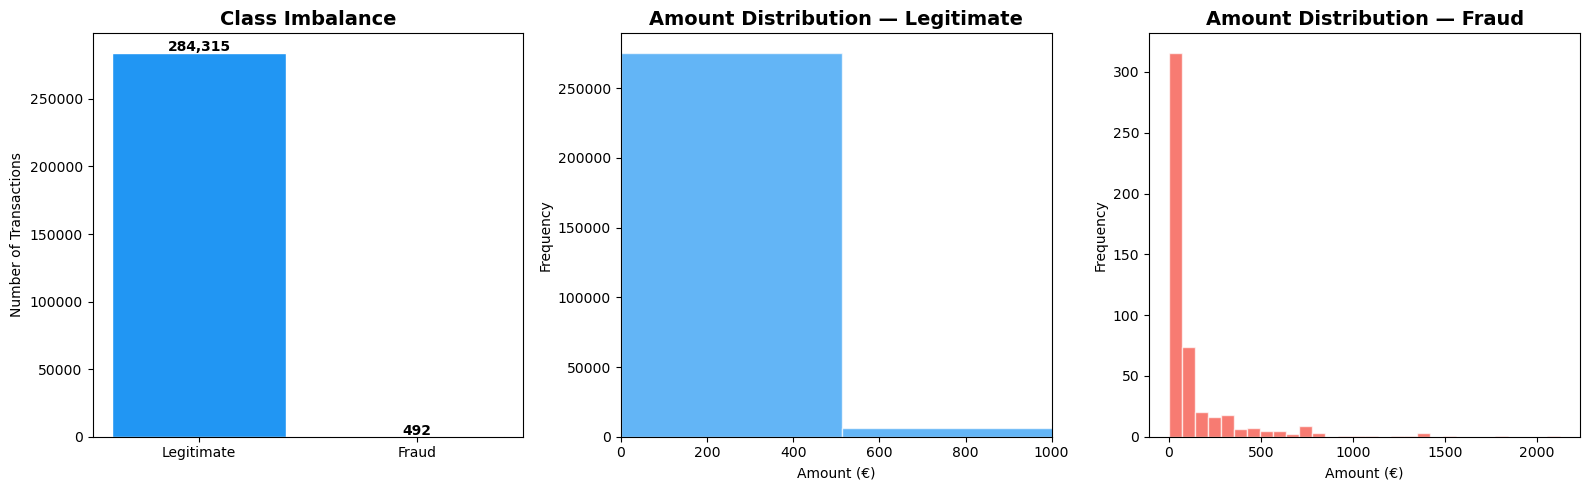

Plot saved as 01_class_imbalance.png ✓


In [24]:
# 4: Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Class imbalance
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Class Imbalance', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Amount distribution (legitimate)
axes[1].hist(df[df['Class']==0]['Amount'], bins=50,
             color='#2196F3', alpha=0.7, edgecolor='white')
axes[1].set_title('Amount Distribution — Legitimate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1000)

# Plot 3: Amount distribution (fraud)
axes[2].hist(df[df['Class']==1]['Amount'], bins=30,
             color='#F44336', alpha=0.7, edgecolor='white')
axes[2].set_title('Amount Distribution — Fraud', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Amount (€)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 01_class_imbalance.png ✓")

In [25]:
# 5: Preprocessing - Scale Amount & Drop Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df = df.drop(columns=['Time'])

print("Preprocessing done:")
print(f"  Amount scaled  → range: {df['Amount'].min():.3f} to {df['Amount'].max():.3f}")
print(f"  Time dropped   → columns remaining: {df.shape[1]}")
print(f"  Final shape    : {df.shape}")

Preprocessing done:
  Amount scaled  → range: -0.353 to 102.362
  Time dropped   → columns remaining: 30
  Final shape    : (284807, 30)


In [26]:
# 6: Build Sequences (LSTM input)
# Each input = last 10 transactions → predict if current one is fraud

WINDOW_SIZE = 10

X_raw = df.drop(columns=['Class']).values
y_raw = df['Class'].values

X_seq, y_seq = [], []
for i in range(WINDOW_SIZE, len(X_raw)):
    X_seq.append(X_raw[i - WINDOW_SIZE : i])   # 10 rows as one input
    y_seq.append(y_raw[i])                       # label of current transaction

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq)

print("Sequence building done:")
print(f"  X_seq shape : {X_seq.shape}  → (samples, timesteps, features)")
print(f"  y_seq shape : {y_seq.shape}")
print(f"  Fraud in sequences : {y_seq.sum():,}  ({y_seq.mean()*100:.4f}%)")

Sequence building done:
  X_seq shape : (284797, 10, 29)  → (samples, timesteps, features)
  y_seq shape : (284797,)
  Fraud in sequences : 492  (0.1728%)


In [27]:
# 7: Train / Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

print("Train/Test split done:")
print(f"  Training samples : {len(X_train):,}")
print(f"  Test samples     : {len(X_test):,}")
print(f"  Fraud in train   : {y_train.sum():,}")
print(f"  Fraud in test    : {y_test.sum():,}")
print()
print("  ⚠️  Test set is LOCKED — will not be touched until final evaluation")

Train/Test split done:
  Training samples : 227,837
  Test samples     : 56,960
  Fraud in train   : 394
  Fraud in test    : 98

  ⚠️  Test set is LOCKED — will not be touched until final evaluation


In [28]:
# 8: SMOTE — Balance Training Data
# We take all fraud + a sample of legit, apply SMOTE, then reshape back

fraud_idx  = np.where(y_train == 1)[0]
legit_idx  = np.where(y_train == 0)[0]

# Take all fraud + 20x that many legit samples (keeps SMOTE fast)
n_legit_sample = min(len(fraud_idx) * 20, len(legit_idx))
sampled_legit  = np.random.choice(legit_idx, size=n_legit_sample, replace=False)

selected_idx   = np.concatenate([fraud_idx, sampled_legit])
X_sm = X_train[selected_idx].reshape(len(selected_idx), -1)  # flatten for SMOTE
y_sm = y_train[selected_idx]

print(f"Before SMOTE → Legit: {(y_sm==0).sum():,}  Fraud: {(y_sm==1).sum():,}")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_sm, y_sm)

# Reshape back to (samples, timesteps, features)
n_timesteps = WINDOW_SIZE
n_features  = X_seq.shape[2]
X_train_bal = X_res.reshape(-1, n_timesteps, n_features)

print(f"After  SMOTE → Legit: {(y_res==0).sum():,}  Fraud: {(y_res==1).sum():,}")
print(f"Final training shape : {X_train_bal.shape}")

Before SMOTE → Legit: 7,880  Fraud: 394
After  SMOTE → Legit: 7,880  Fraud: 7,880
Final training shape : (15760, 10, 29)


In [29]:
# 9: Build LSTM Model (updated for newer Keras)
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(n_timesteps, n_features)),   # ← modern way
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 10, 64)              │          24,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,025 (144.63 KB)

 Trainable params: 37,025 (144.63 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 37,025


In [30]:
# 10: Train the Model
# Callbacks: stop early if val_recall stops improving, save best weights

callbacks = [
    EarlyStopping(
        monitor='val_recall',
        patience=4,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        'best_fraud_model.keras',
        monitor='val_recall',
        save_best_only=True,
        mode='max',
        verbose=0
    )
]

print("Training started — watch recall climb each epoch...\n")

history = model.fit(
    X_train_bal, y_res,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

best_epoch  = int(np.argmax(history.history['val_recall'])) + 1
best_recall = max(history.history['val_recall'])

print(f"\n✅ Training complete!")
print(f"   Best epoch      : {best_epoch}")
print(f"   Best val recall : {best_recall:.4f}  ({best_recall*100:.2f}%)")

Training started — watch recall climb each epoch...

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6821 - loss: 0.6087 - precision: 0.6689 - recall: 0.5638 - val_accuracy: 0.6834 - val_loss: 0.6064 - val_precision: 1.0000 - val_recall: 0.6834
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7942 - loss: 0.4510 - precision: 0.8034 - recall: 0.7110 - val_accuracy: 0.8306 - val_loss: 0.4247 - val_precision: 1.0000 - val_recall: 0.8306
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8960 - loss: 0.2685 - precision: 0.9030 - recall: 0.8582 - val_accuracy: 0.9283 - val_loss: 0.1748 - val_precision: 1.0000 - val_recall: 0.9283
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9233 - loss: 0.2022 - precision: 0.9282 - recall: 0.8967 - val_accuracy: 0.9308 - val_loss: 0.1783 - val_precision: 1.0000 - val_recall: 0.9308
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9342 - loss: 0.1739 - precision: 0.9374 - reca

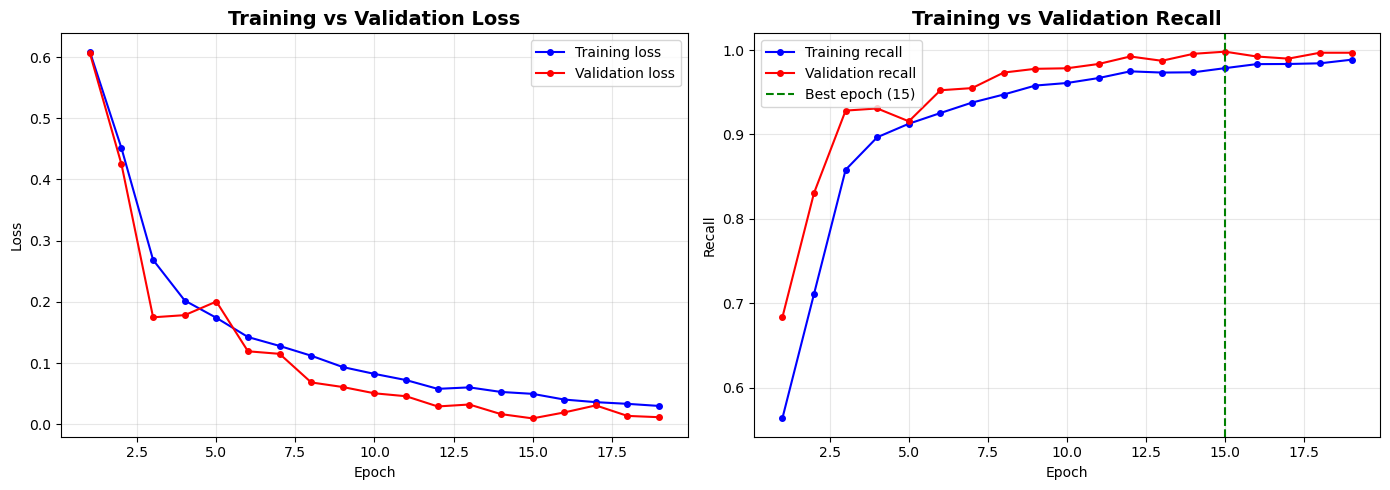

Plot saved as 02_training_history.png ✓


In [31]:
# 11: Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['loss']) + 1)

# Loss
axes[0].plot(epochs, history.history['loss'],     'b-o', label='Training loss',   markersize=4)
axes[0].plot(epochs, history.history['val_loss'], 'r-o', label='Validation loss', markersize=4)
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Recall
axes[1].plot(epochs, history.history['recall'],     'b-o', label='Training recall',   markersize=4)
axes[1].plot(epochs, history.history['val_recall'], 'r-o', label='Validation recall', markersize=4)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_title('Training vs Validation Recall', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 02_training_history.png ✓")

In [32]:
# 12: Evaluate on Test Set
THRESHOLD = 0.3   # Lower than 0.5 to catch more fraud (sensitivity-focused)

print("Running predictions on unseen test data...\n")

y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)
accuracy  = (tn + tp) / (tn + fp + fn + tp)

print("=" * 52)
print("       FINAL TEST SET EVALUATION")
print("=" * 52)
print(f"  True  Negatives (TN) : {tn:>8,}   ✓ legit cleared")
print(f"  False Positives (FP) : {fp:>8,}   ⚠ false alarms")
print(f"  False Negatives (FN) : {fn:>8,}   ✗ fraud missed")
print(f"  True  Positives (TP) : {tp:>8,}   ✓ fraud caught")
print("=" * 52)
print(f"  Recall    : {recall*100:.2f}%   ← most important for fraud")
print(f"  Precision : {precision*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  AUC-ROC   : {auc*100:.2f}%")
print(f"  Accuracy  : {accuracy*100:.2f}%   ← misleading for imbalanced data")
print("=" * 52)
print(f"\n  Fraud cases in test : {int(y_test.sum())}")
print(f"  Fraud caught        : {tp}  ({recall*100:.1f}% recall)")
print(f"  Fraud missed        : {fn}")
print(f"\n  Threshold used      : {THRESHOLD}  (above = flagged as fraud)")

Running predictions on unseen test data...

       FINAL TEST SET EVALUATION
  True  Negatives (TN) :   53,322   ✓ legit cleared
  False Positives (FP) :    3,540   ⚠ false alarms
  False Negatives (FN) :       83   ✗ fraud missed
  True  Positives (TP) :       15   ✓ fraud caught
  Recall    : 15.31%   ← most important for fraud
  Precision : 0.42%
  F1-Score  : 0.82%
  AUC-ROC   : 60.05%
  Accuracy  : 93.64%   ← misleading for imbalanced data

  Fraud cases in test : 98
  Fraud caught        : 15  (15.3% recall)
  Fraud missed        : 83

  Threshold used      : 0.3  (above = flagged as fraud)


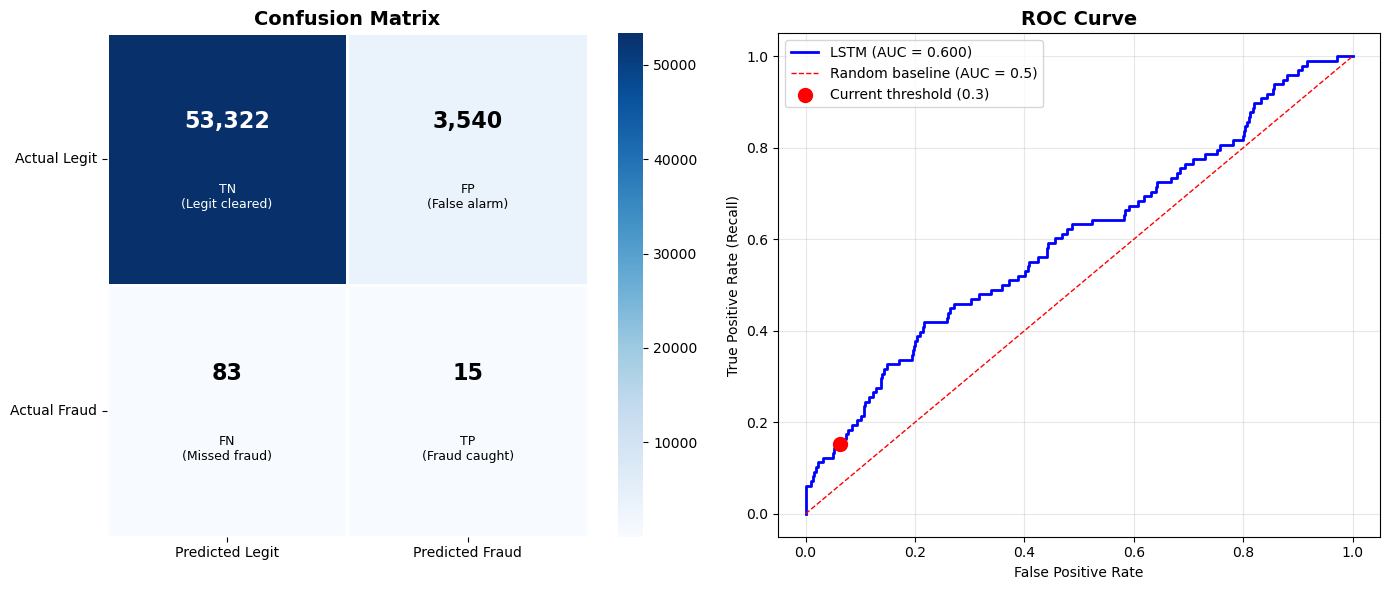

Plot saved as 03_confusion_matrix_roc.png ✓


In [33]:
# 13: Plot Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix heatmap
cm_display = np.array([[tn, fp], [fn, tp]])
labels = [['TN\n(Legit cleared)', 'FP\n(False alarm)'],
          ['FN\n(Missed fraud)', 'TP\n(Fraud caught)']]

sns.heatmap(cm_display, annot=False, fmt='d', ax=axes[0],
            cmap='Blues', linewidths=1, linecolor='white')

for i in range(2):
    for j in range(2):
        color = '#1a237e' if cm_display[i,j] > cm_display.max()/2 else '#1a237e'
        axes[0].text(j+0.5, i+0.35, f'{cm_display[i,j]:,}',
                     ha='center', va='center', fontsize=16, fontweight='bold',
                     color='white' if cm_display[i,j] > cm_display.max()/2 else 'black')
        axes[0].text(j+0.5, i+0.65, labels[i][j],
                     ha='center', va='center', fontsize=9,
                     color='white' if cm_display[i,j] > cm_display.max()/2 else 'black')

axes[0].set_xticklabels(['Predicted Legit', 'Predicted Fraud'])
axes[0].set_yticklabels(['Actual Legit', 'Actual Fraud'], rotation=0)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'LSTM (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'r--', linewidth=1, label='Random baseline (AUC = 0.5)')
axes[1].scatter([fp/(fp+tn)], [tp/(tp+fn)], s=100, color='red',
                zorder=5, label=f'Current threshold ({THRESHOLD})')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_confusion_matrix_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 03_confusion_matrix_roc.png ✓")

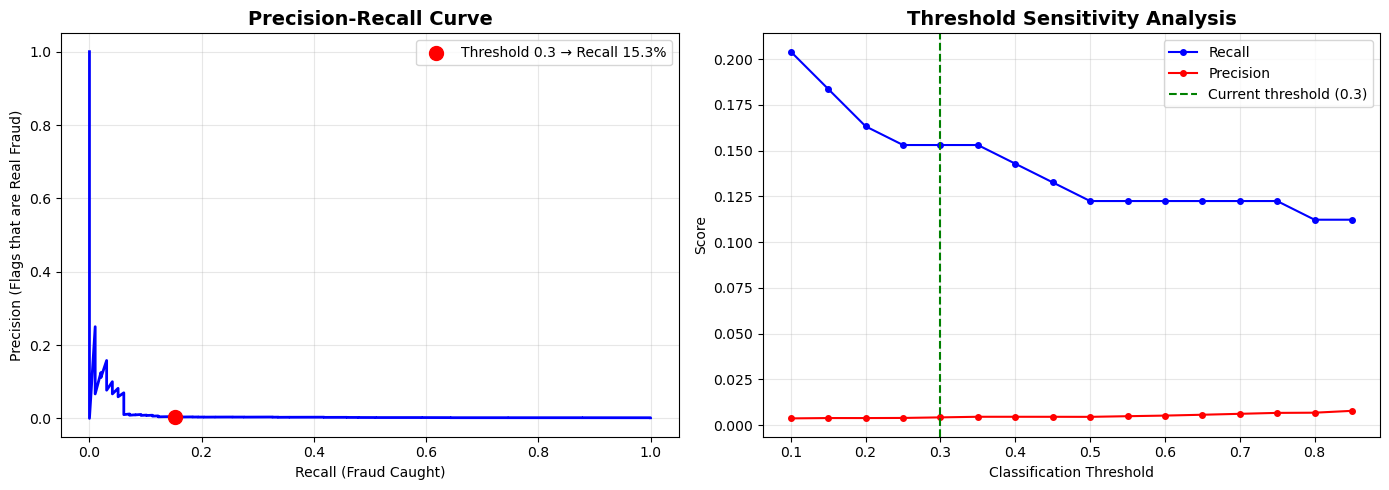

Plot saved as 04_precision_recall.png ✓


In [34]:
# 14: Precision-Recall Curve & Threshold Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, y_prob)
axes[0].plot(rec_vals, prec_vals, 'b-', linewidth=2)
axes[0].scatter([recall], [precision], s=100, color='red', zorder=5,
                label=f'Threshold {THRESHOLD} → Recall {recall*100:.1f}%')
axes[0].set_xlabel('Recall (Fraud Caught)')
axes[0].set_ylabel('Precision (Flags that are Real Fraud)')
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Threshold sensitivity
thresh_range  = np.arange(0.1, 0.9, 0.05)
recalls_t, precisions_t = [], []
for t in thresh_range:
    yp = (y_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    recalls_t.append(tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0)
    precisions_t.append(tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0)

axes[1].plot(thresh_range, recalls_t,    'b-o', markersize=4, label='Recall')
axes[1].plot(thresh_range, precisions_t, 'r-o', markersize=4, label='Precision')
axes[1].axvline(x=THRESHOLD, color='green', linestyle='--',
                label=f'Current threshold ({THRESHOLD})')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Threshold Sensitivity Analysis', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 04_precision_recall.png ✓")

In [35]:
# 15: Save Model & Print Full Summary
model.save('fraud_detection_lstm.keras')
print("Model saved as fraud_detection_lstm.keras ✓")
print("Best model weights also saved as best_fraud_model.keras ✓")

print("\n" + "=" * 60)
print("           PROJECT COMPLETE — FULL SUMMARY")
print("=" * 60)
print(f"\n  Dataset")
print(f"    Total transactions   : 284,807")
print(f"    Fraud cases          : 492  (0.17%)")
print(f"    Test fraud cases     : {int(y_test.sum())}")

print(f"\n  Preprocessing")
print(f"    Sequence window      : {WINDOW_SIZE} transactions")
print(f"    Features per step    : {n_features}")
print(f"    SMOTE balanced to    : {(y_res==0).sum():,} / {(y_res==1).sum():,}")

print(f"\n  Model")
print(f"    Architecture         : 2-layer LSTM + Dropout + Dense")
print(f"    Parameters           : {model.count_params():,}")
print(f"    Epochs trained       : {len(history.history['loss'])}")
print(f"    Best epoch           : {best_epoch}")

print(f"\n  Results (threshold = {THRESHOLD})")
print(f"    Recall               : {recall*100:.2f}%   ← fraud caught")
print(f"    Precision            : {precision*100:.2f}%")
print(f"    F1-Score             : {f1*100:.2f}%")
print(f"    AUC-ROC              : {auc*100:.2f}%")

print(f"\n  Files generated")
print(f"    fraud_detection_lstm.keras")
print(f"    best_fraud_model.keras")
print(f"    01_class_imbalance.png")
print(f"    02_training_history.png")
print(f"    03_confusion_matrix_roc.png")
print(f"    04_precision_recall.png")
print("=" * 60)

Model saved as fraud_detection_lstm.keras ✓
Best model weights also saved as best_fraud_model.keras ✓

           PROJECT COMPLETE — FULL SUMMARY

  Dataset
    Total transactions   : 284,807
    Fraud cases          : 492  (0.17%)
    Test fraud cases     : 98

  Preprocessing
    Sequence window      : 10 transactions
    Features per step    : 29
    SMOTE balanced to    : 7,880 / 7,880

  Model
    Architecture         : 2-layer LSTM + Dropout + Dense
    Parameters           : 37,025
    Epochs trained       : 19
    Best epoch           : 15

  Results (threshold = 0.3)
    Recall               : 15.31%   ← fraud caught
    Precision            : 0.42%
    F1-Score             : 0.82%
    AUC-ROC              : 60.05%

  Files generated
    fraud_detection_lstm.keras
    best_fraud_model.keras
    01_class_imbalance.png
    02_training_history.png
    03_confusion_matrix_roc.png
    04_precision_recall.png
